Sequence Labeling Accuracy: 66.67 %

Sentence: book flight from mumbai to delhi
Words: ['book', 'flight', 'from', 'mumbai', 'to', 'delhi']
Predicted Labels: [0 0 0 0 0 0]


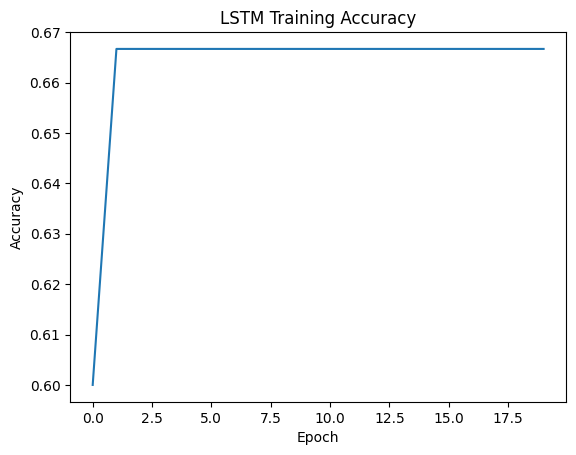

In [ ]:

# riya_varma_23070521118

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

sentences = [
    "book flight from mumbai to delhi",
    "fly from pune to mumbai",
    "flight from delhi to bangalore",
    "travel from mumbai to pune",
    "book ticket from chennai to delhi"
]

labels = [
    ["O","O","O","B-from","O","B-to"],
    ["O","O","O","B-from","O","B-to"],
    ["O","O","O","B-from","O","B-to"],
    ["O","O","O","B-from","O","B-to"],
    ["O","O","O","B-from","O","B-to"]
]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

X = tokenizer.texts_to_sequences(sentences)
X = pad_sequences(X, padding="post")

label_map = {"O": 0, "B-from": 1, "B-to": 2}
y = [[label_map[x] for x in row] for row in labels]
y = pad_sequences(y, maxlen=X.shape[1], padding="post")
model = Sequential([
    Embedding(len(tokenizer.word_index) + 1, 16),
    LSTM(32, return_sequences=True),
    Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X, np.expand_dims(y, -1),
    epochs=20,
    verbose=0
)

loss, accuracy = model.evaluate(
    X, np.expand_dims(y, -1), verbose=0
)

print("Sequence Labeling Accuracy:", round(accuracy * 100, 2), "%")

# 4. Prediction
pred = model.predict(X, verbose=0)
pred = np.argmax(pred, axis=-1)

print("\nSentence:", sentences[0])
print("Words:", sentences[0].split())
print("Predicted Labels:", pred[0][:len(sentences[0].split())])

# 5. Visual 1: Training Accuracy
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training Accuracy")
plt.show()